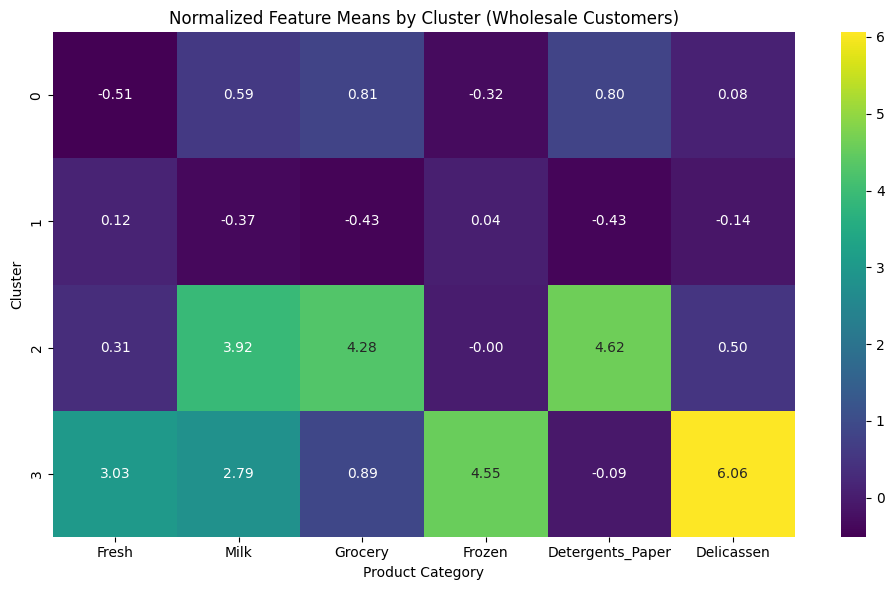

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read the Wholesale Customers dataset from GitHub
url = "https://raw.githubusercontent.com/majidramzi/clustering/refs/heads/main/wholesale-customers/wholesale-customers.csv"
df = pd.read_csv(url)

# Isolate the continuous spending features
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[features]

# Apply Feature Scaling (critical for multi-dimensional spending data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Extract the normalized cluster centers for visualization
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)

# Generate a heatmap of the cluster centers
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_centers, annot=True, cmap='viridis', fmt=".2f")
plt.title('Normalized Feature Means by Cluster (Wholesale Customers)')
plt.ylabel('Cluster')
plt.xlabel('Product Category')
plt.tight_layout()
plt.show()

The Wholesale Customers dataset contains continuous spending data across six distinct product categories. Because the spending magnitudes vary drastically between categories (e.g., massive spending on fresh groceries versus minimal spending on delicatessen items), feature scaling was applied to ensure every variable influenced the K-Means distance calculations equally. The algorithm clustered the data into four primary customer segments, best interpreted through a normalized heatmap of the cluster centers.

Cluster 0 identifies small-scale buyers who consistently spend below the average across all categories. Cluster 1 represents general grocery retailers or supermarkets, characterized by exceptionally high spending in Grocery, Milk, and Detergents_Paper. Cluster 2 captures a rare segment of bulk wholesale buyers who purchase heavily across every single category, dominating the upper extremes of the dataset. Cluster 3 consists primarily of fresh food markets or specific restaurants, showing strong above-average spending heavily concentrated in the Fresh and Frozen categories.